TARGET
0    240326
1     21057
Name: count, dtype: int64
TARGET
0    0.91944
1    0.08056
Name: proportion, dtype: float64


FileNotFoundError: [Errno 2] No such file or directory: 'E:\\senior_ds_test\\senior_ds_test\\reports\\figures\\class_balance.png'

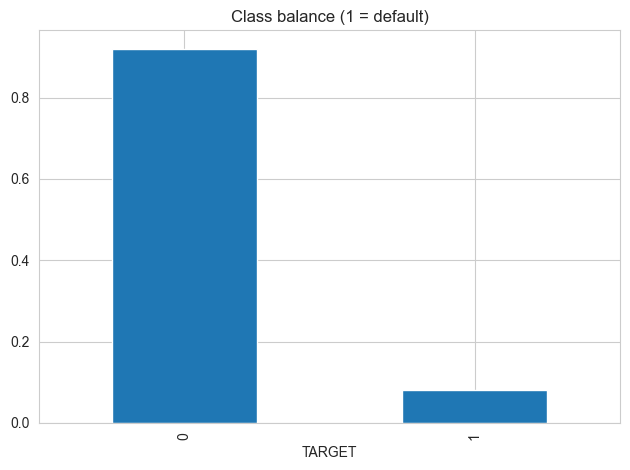

In [3]:
# Cell 1
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_data import load_train
from src.data.preprocessing import clean_accounts, clean_enquiries
from src.data.validation import validate_payment_history
from src.utils import config

sns.set_style('whitegrid')
flag, acc, enq = load_train()

# Cell 2 — Class balance
print(flag['TARGET'].value_counts())
print(flag['TARGET'].value_counts(normalize=True))

flag['TARGET'].value_counts(normalize=True).plot.bar()
plt.title('Class balance (1 = default)')
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'class_balance.png', dpi=120)
plt.show()

# Cell 3 — Default rate by contract type
print(flag['NAME_CONTRACT_TYPE'].value_counts())
flag.groupby('NAME_CONTRACT_TYPE')['TARGET'].mean()

# Cell 4 — Accounts EDA
acc_c = clean_accounts(acc)
print('accounts per applicant:\n', acc_c.groupby('uid').size().describe())
print('\ncredit types:\n', acc_c['credit_type'].value_counts())
print('\n% with overdue > 0:', (acc_c['amount_overdue'] > 0).mean())
print('% still open:', acc_c['is_open'].mean())

# Cell 5
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
acc_c.groupby('uid').size().clip(upper=30).hist(bins=30, ax=axes[0])
axes[0].set_title('Accounts per applicant')
np.log1p(acc_c['loan_amount']).hist(bins=50, ax=axes[1])
axes[1].set_title('log(1 + loan_amount)')
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'accounts_eda.png', dpi=120)
plt.show()

# Cell 6 — Payment-history validation
validate_payment_history(acc)

# Cell 7
def parse_ph(s):
    s = str(s)
    if len(s) < 3:
        return []
    return [int(s[i:i+3]) for i in range(0, len(s) - len(s) % 3, 3)]

sample_vals = []
for s in acc['payment_hist_string'].sample(20000, random_state=1):
    sample_vals.extend(parse_ph(s))
sv = pd.Series(sample_vals)

print('% months with DPD>0:', (sv > 0).mean())
print('DPD buckets:')
print(pd.cut(sv, [-1, 0, 29, 59, 89, 119, 10000]).value_counts().sort_index())
print('\nsentinel 999 count:', (sv == 999).sum())

# Cell 8 — Enquiry recency
enq_c = clean_enquiries(enq)
span = enq_c.groupby('uid')['enquiry_date'].agg(['min', 'max'])
span['span_days'] = (span['max'] - span['min']).dt.days
span['span_days'].describe()